# Factor Graph

A factor graph is a bipartite graphical representation of the factorization of a function.

Suppose a function over variables $X_1,\dots,X_n$ can be written as

$$F(X_1,\dots,X_n)=
\prod_{i=1}^{m}\phi_i(\mathbf{X}_i),
$$

where each factor $\phi_i$ depends only on a subset $\mathbf{X}_i$ of the complete variable set.

A factor graph contains:

- one variable node for every variable,
- one factor node for every factor,
- an edge between a variable and a factor whenever the variable belongs to the scope of that factor.

**Factor graphs are bipartite:** variable nodes connect only to factor nodes, and factor nodes connect only to variable nodes.

## Implementation

In [5]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Hashable, Mapping

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [6]:
%%capture
%run "../01_Representation/05_DiscreteFactor.ipynb"

In [22]:
@dataclass
class FactorGraph:
    """
    A bipartite graphical representation of a collection of factors.

    The graph contains two types of nodes:

    - variable nodes
    - factor nodes

    A factor node is connected to every variable in its scope.

    Parameters
    ----------
    factors:
        Mapping from unique factor names to `Factor` objects.

        Example
        -------
        {
            "phi_A": factor_a,
            "phi_B_given_A": factor_b_given_a,
        }
    """

    factors: Mapping[str, Factor]

    graph: nx.Graph = field(
        init=False,
        repr=False,
    )

    domains: dict[str, np.ndarray] = field(
        init=False,
        repr=False,
    )

    def __post_init__(self) -> None:
        self.factors = dict(self.factors)

        self._validate_parameters()
        self._collect_domains()
        self._build_graph()

    def _validate_parameters(self) -> None:
        """
        Validate the factors supplied to the graph.
        """

        if not isinstance(self.factors, Mapping):
            raise TypeError(
                "`factors` must be a mapping from factor names "
                "to Factor objects."
            )

        if len(self.factors) == 0:
            if not isinstance(factor_name, str):
                raise TypeError(
                    "Every factor name must be a string."
                )

            if factor_name.strip() == "":
                raise ValueError(
                    "Factor names cannot be empty."
                )

            if not isinstance(factor, Factor):
                raise TypeError(
                    f"The object associated with {factor_name!r} "
                    "must be a Factor instance."
                )

            if len(factor.variables) == 0:
                raise ValueError(
                    f"Factor {factor_name!r} has an empty scope."
                )

    def _collect_domains(self) -> None:
        """
        Collect variable domains from all factors.

        If a variable appears in multiple factors, its domain must be
        identical in every factor.
        """

        self.domains = {}

        for factor_name, factor in self.factors.items():
            for variable in factor.variables:
                factor_domain = np.asarray(
                    factor.domains[variable],
                    dtype=object
                )

                if variable not in self.domains:
                    self.domains[variable] = factor_domain.copy()
                    continue

                stored_domain = self.domains[variable]

                # check if the stored variable domain matches the domain in the factor
                if not np.array_equal(
                    stored_domain,
                    factor_domain,
                ):
                    raise ValueError(
                        f"Inconsistent domain for variable "
                        f"{variable!r} in factor {factor_name!r}.\n"
                        f"Existing domain: {stored_domain.tolist()}\n"
                        f"New domain: {factor_domain.tolist()}"
                    )

    def _build_graph(self) -> None:
        """
        Construct the bipartite NetworkX graph.
        """
        self.graph = nx.Graph()

        for variable in self.domains:
            self.graph.add_node(
                self._variable_node_id(variable),
                bipartite="variable",
                node_type="variable",
                label=variable,
                variable=variable,
            )

        for factor_name, factor in self.factors.items():
            factor_node = self._factor_node_id(factor_name)

            self.graph.add_node(
                factor_node,
                bipartite="factor",
                node_type="factor",
                label=factor_name,
                factor_name=factor_name,
            )

            for variable in factor.variables:
                variable_node = self._variable_node_id(variable)

                self.graph.add_edge(
                    variable_node,
                    factor_node,
                )


    @staticmethod
    def _variable_node_id(variable: str) -> tuple[str, str]:
        """
        Return the internal graph identifier for a variable node.

        Tuple identifiers prevent collisions between variable and
        factor names.
        """

        return "variable", variable

    @staticmethod
    def _factor_node_id(factor_name: str) -> tuple[str, str]:
        """
        Return the internal graph identifier for a factor node.
        """

        return "factor", factor_name

    @property
    def variables(self) -> list[str]:
        """
        Return all variable names.
        """

        return list(self.domains)

    @property
    def factor_names(self) -> list[str]:
        """
        Return all factor names.
        """

        return list(self.factors)

    def get_factor(self, factor_name: str) -> Factor:
        """
            Return a factor by name.
        """
    
        if factor_name not in self.factors:
            raise KeyError(
                    f"Unknown factor {factor_name!r}."
            )
    
        return self.factors[factor_name]
        
    def get_domain(
            self,
            variable: str,
        ) -> np.ndarray:
            """
            Return a copy of the domain of a variable.
            """
    
            if variable not in self.domains:
                raise KeyError(
                    f"Unknown variable {variable!r}."
                )
    
            return self.domains[variable].copy()        

    def incident_factors(
            self,
            variable: str,
        ) -> list[str]:
            """
            Return all factors connected to a variable.
            """
    
            if variable not in self.domains:
                raise KeyError(
                    f"Unknown variable {variable!r}."
                )
    
            variable_node = self._variable_node_id(variable)
    
            return [
                node_name
                for node_type, node_name
                in self.graph.neighbors(variable_node)
                if node_type == "factor"
            ]

    def incident_variables(
            self,
            factor_name: str,
        ) -> list[str]:
            """
            Return all variables connected to a factor.
            """
    
            if factor_name not in self.factors:
                raise KeyError(
                    f"Unknown factor {factor_name!r}."
                )
    
            factor_node = self._factor_node_id(factor_name)
    
            connected_variables = {
                node_name
                for node_type, node_name
                in self.graph.neighbors(factor_node)
                if node_type == "variable"
            }
    
            # Preserve the scope order defined by the Factor object.
            return [
                variable
                for variable
                in self.factors[factor_name].variables
                if variable in connected_variables
            ]

    def neighbors(
        self,
        node_name: str,
        node_type: str,
    ) -> list[str]:
        """
        Return the neighboring nodes of a variable or factor.

        Parameters
        ----------
        node_name:
            Variable name or factor name.

        node_type:
            Either `"variable"` or `"factor"`.
        """

        if node_type == "variable":
            return self.incident_factors(node_name)

        if node_type == "factor":
            return self.incident_variables(node_name)

        raise ValueError(
            "`node_type` must be either 'variable' or 'factor'."
        )

    def is_tree(self) -> bool:
        """
        Return True if the factor graph is connected and acyclic.
        """

        return nx.is_tree(self.graph)

    def is_connected(self) -> bool:
        """
        Return True if every node belongs to one connected component.
        """

        return nx.is_connected(self.graph)

    def validate_bipartite(self) -> bool:
        """
        Check whether the graph is bipartite.
        """

        return nx.is_bipartite(self.graph)

    def plot(
        self,
        figsize: tuple[float, float] = (10.0, 6.0),
        with_labels: bool = True,
    ) -> None:
        """
        Visualize the factor graph.

        Variable nodes are drawn as circles.
        Factor nodes are drawn as squares.
        """

        variable_nodes = [
            node
            for node, attributes in self.graph.nodes(data=True)
            if attributes["node_type"] == "variable"
        ]

        factor_nodes = [
            node
            for node, attributes in self.graph.nodes(data=True)
            if attributes["node_type"] == "factor"
        ]

        labels = {
            node: attributes["label"]
            for node, attributes in self.graph.nodes(data=True)
        }

        position = nx.spring_layout(
            self.graph,
            seed=42,
        )

        plt.figure(figsize=figsize)

        nx.draw_networkx_edges(
            self.graph,
            position,
        )

        nx.draw_networkx_nodes(
            self.graph,
            position,
            nodelist=variable_nodes,
            node_shape="o",
            node_size=1800,
        )

        nx.draw_networkx_nodes(
            self.graph,
            position,
            nodelist=factor_nodes,
            node_shape="s",
            node_size=1500,
        )

        if with_labels:
            nx.draw_networkx_labels(
                self.graph,
                position,
                labels=labels,
            )

        plt.title("Factor Graph")
        plt.axis("off")
        plt.show()

    def __repr__(self) -> str:
        return (
            "FactorGraph("
            f"variables={self.variables}, "
            f"factors={self.factor_names}, "
            f"edges={self.graph.number_of_edges()}"
            ")"
        )

In [11]:
factor_a = Factor(
    variables=["A"],
    domains={
        "A": [0, 1],
    },
    values=np.array([
        0.6,
        0.4,
    ]),
    name="P(A)",
)

factor_b_given_a = Factor(
    variables=["A", "B"],
    domains={
        "A": [0, 1],
        "B": [0, 1],
    },
    values=np.array([
        [0.7, 0.3],
        [0.2, 0.8],
    ]),
    name="P(B|A)",
)

factor_c_given_b = Factor(
    variables=["B", "C"],
    domains={
        "B": [0, 1],
        "C": [0, 1],
    },
    values=np.array([
        [0.9, 0.1],
        [0.4, 0.6],
    ]),
    name="P(C|B)",
)

In [12]:
factor_graph = FactorGraph(
    factors={
        "phi_A": factor_a,
        "phi_B_given_A": factor_b_given_a,
        "phi_C_given_B": factor_c_given_b,
    }
)

In [13]:
factor_graph

FactorGraph(variables=['A', 'B', 'C'], factors=['phi_A', 'phi_B_given_A', 'phi_C_given_B'], edges=5)

In [14]:
factor_graph.incident_factors("B")

['phi_B_given_A', 'phi_C_given_B']

In [15]:
factor_graph.incident_variables(
    "phi_B_given_A"
)

['A', 'B']

In [16]:
print(factor_graph.validate_bipartite())
print(factor_graph.is_connected())
print(factor_graph.is_tree())

True
True
True


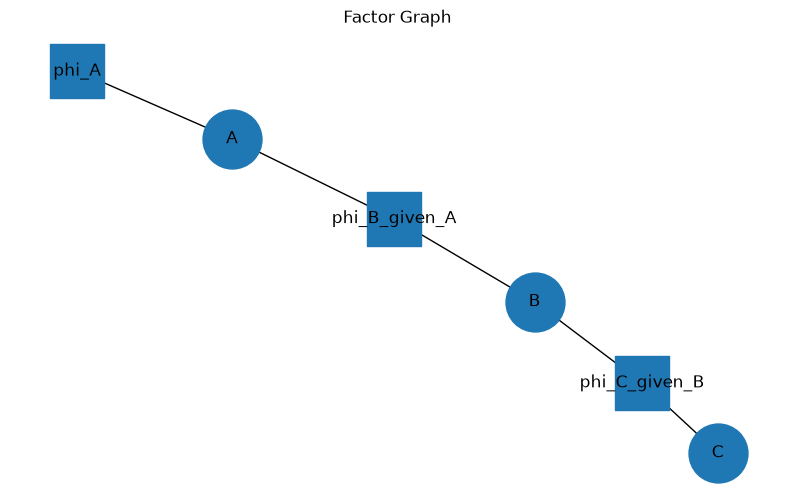

In [17]:
factor_graph.plot()